<a href="https://colab.research.google.com/github/manaswinialakunta08/machine-learning/blob/main/FeatureSelection_And_PCA_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Standardized data:
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]]

Selected feature indices:
[2 3]

Selected features:
['petal_length', 'petal_width']

Explained variance ratio:
[0.92461872 0.05306648]

Cumulative explained variance:
[0.92461872 0.97768521]

Transformed data after PCA:
[[-2.68412563  0.31939725]
 [-2.71414169 -0.17700123]
 [-2.88899057 -0.14494943]
 [-2.74534286 -0.31829898]
 [-2.72871654  0.32675451]
 [-2.28085963  0.74133045]
 [-2.82053775 -0.08946138]
 [-2.62614497  0.16338496]
 [-2.88638273 -0.57831175]
 [-2.6727558  -0.11377425]
 [-2.50694709  0.6450689 ]
 [-2.61275523  0.01472994]
 [-2.78610927 -0.235112  ]
 [-3.22380374 -0.51139459]
 [-2.64475039  1.17876464]
 [-2.38603903  1.33806233]
 [-2.62352788  0.81067951]
 [-2.64829671  0.31184914]
 [-2.19982032  0.87283904]
 [-2.5879864   0.51356031]
 [-2.31025622  0.39134594]
 [-2.54370523  0.43299606]
 [-3.21593942  0.13346807]
 [-2.30273318  0.09870885]
 [-2.3557

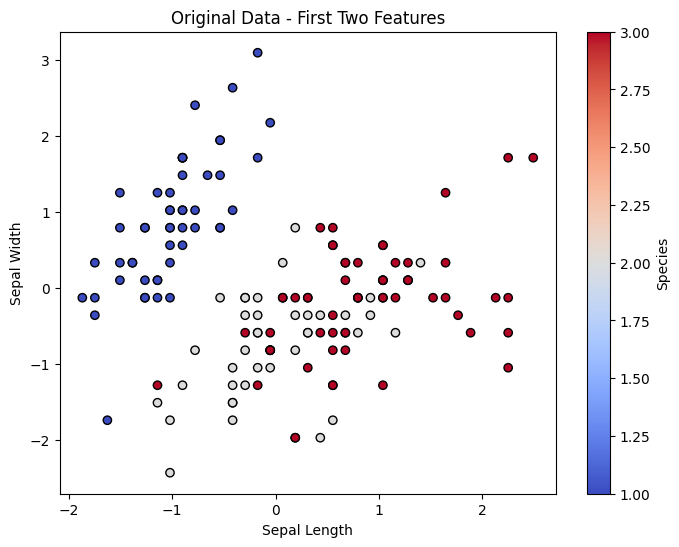

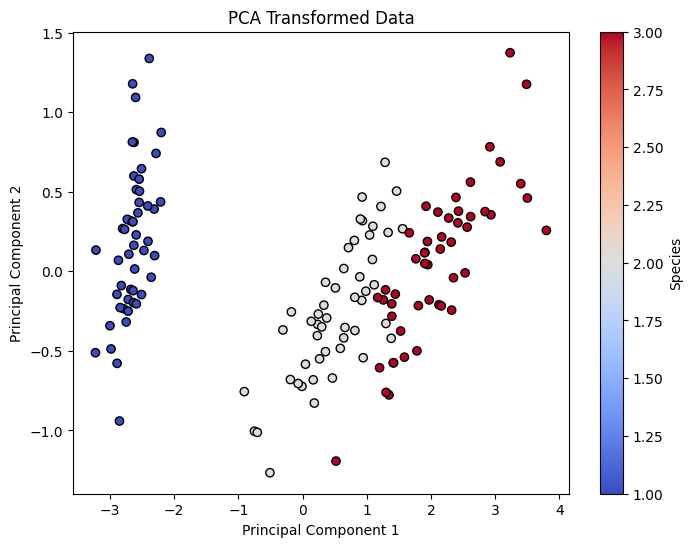

In [1]:
# Import necessary libraries
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# 1. Load Iris dataset
df = sns.load_dataset('iris')

# Separate features
X = df.drop('species', axis=1)

# Convert target labels into numbers
df['species'] = df['species'].map({
    'setosa': 1,
    'versicolor': 2,
    'virginica': 3
})

Y = df['species']


# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Standardized data:")
print(X_scaled[:2])


# 2. Feature Subset Selection

selector = SelectKBest(score_func=chi2, k=2)

X_new = selector.fit_transform(X, Y)

print("\nSelected feature indices:")
selected_features = selector.get_support(indices=True)
print(selected_features)

print("\nSelected features:")
print(X.columns[selected_features].tolist())


# 3. Dimensionality Reduction using PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nCumulative explained variance:")
print(np.cumsum(pca.explained_variance_ratio_))


print("\nTransformed data after PCA:")
print(X_pca)


# 4. Visualization Before PCA

plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=Y,
    cmap='coolwarm',
    edgecolor='k'
)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Original Data - First Two Features")
plt.colorbar(label="Species")

plt.show()


# 5. Visualization After PCA

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=Y,
    cmap='coolwarm',
    edgecolor='k'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Transformed Data")
plt.colorbar(label="Species")

plt.show()